In [9]:
import pandas as pd
import matplotlib.pyplot as plt
pip install pandasql
from pandasql import sqldf

SyntaxError: invalid syntax (407172930.py, line 3)

### Radio

In [10]:
radio = pd.read_csv("/content/radio.csv")
radio.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/radio.csv'

In [11]:
radio = radio.rename(columns = {"Imp's": "radio_impression"})

NameError: name 'radio' is not defined

In [12]:
radio.shape

NameError: name 'radio' is not defined

In [ ]:
radio.isnull().sum()

,0
Title,0
radio_impression,0


In [ ]:
radio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Title             325 non-null    object
 1   radio_impression  325 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 5.2+ KB


In [ ]:
radio['Title'].is_unique

True

In [ ]:
radio['Title'].duplicated().sum()

np.int64(0)

In [ ]:
query = "SELECT * FROM radio ORDER BY radio_impression DESC Limit 10"
radio_table = sqldf(query, globals())
radio_table

,Title,radio_impression
0,Ijo (Laba Laba),53595389
1,Certified Loner (No Competition),52281640
2,Peace Be Unto You (PBUY),51681908
3,Girlfriend,50647245
4,Bandana,49512679
5,i'm a mess,45410610
6,It's Plenty,43991485
7,Overloading (OVERDOSE),42040415
8,For My Hand,41971163
9,Buga (Lo Lo Lo),40729277


In [ ]:
query = "SELECT Title, min(radio_impression) AS MIN_IMP FROM radio"
sqldf(query, globals())

,Title,MIN_IMP
0,Way Too Big,661700


## Youtube Data

In [ ]:
youtube = pd.read_csv("/content/youtube.csv")
youtube.head(10)

,No,Artiste,Song,Difference
0,1,Burna Boy,Higher (Burna Boy),629155
1,2,BoyPee & Hyce &,Ogechi,473394
2,3,Rema & Shallipopi,BENIN BOYS,401094
3,4,TitoM & Yuppe,Tshwala Bam,335433
4,5,Olamide,Metaverse,321520
5,6,Asake & Central Cee,Wave,305411
6,7,Chris Brown,Hmmm,287636
7,8,LISA,Rockstar (LISA),238145
8,9,Lee Young Ji,Small girl,228623
9,10,Olamide & Fireboy DML & Asake,Uptown Disco,220996


In [ ]:
youtube = youtube.rename(columns={"Artiste": "Artist", "Song" : "Title", "Difference" : "Youtube_stream"})
youtube.head()

,No,Artist,Title,Youtube_stream
0,1,Burna Boy,Higher (Burna Boy),629155
1,2,BoyPee & Hyce &,Ogechi,473394
2,3,Rema & Shallipopi,BENIN BOYS,401094
3,4,TitoM & Yuppe,Tshwala Bam,335433
4,5,Olamide,Metaverse,321520


In [ ]:
youtube.shape

(100, 4)

In [ ]:
youtube.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   No              100 non-null    int64 
 1   Artist          100 non-null    object
 2   Title           100 non-null    object
 3   Youtube_stream  100 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 3.3+ KB


In [ ]:
youtube.describe()

,No,Youtube_stream
count,100.000000,100.000000
mean,50.500000,113113.570000
std,29.011492,93653.103971
min,1.000000,47073.000000
25%,25.750000,61669.000000
50%,50.500000,79902.000000
75%,75.250000,125640.500000
max,100.000000,629155.000000


In [ ]:
youtube.isnull().sum()

,0
No,0
Artist,0
Title,0
Youtube_stream,0


In [ ]:
youtube['Artist'].duplicated().sum()

np.int64(21)

### Artists with the highest number of songs

In [ ]:
artist_group =  youtube.groupby('Artist')['Title'].count().sort_values(ascending=False)
artist_group.head(15)

,Title
Artist,
NewJeans,6
Olamide,5
DAY6,3
Kizz Daniel,3
Ayra Starr,2
BABYMONSTER,2
Sabrina Carpenter,2
Ruger & BNXN,2
aespa,2


### Identify and display dropped duplicates

In [ ]:
youtube_original = pd.read_csv("/content/youtube.csv")
youtube_original = youtube_original.rename(columns={"Artiste": "Artist", "Song" : "Title", "Difference" : "Youtube_stream"})

dropped_duplicates = youtube_original[youtube_original.duplicated(subset=['Title'], keep=False)].sort_values(by='Title')
display(dropped_duplicates)

,No,Artist,Title,Youtube_stream
1,2,BoyPee & Hyce &,Ogechi,473394
13,14,Brown Joel & BoyPee & Hyce,Ogechi,176527


In [ ]:
youtube = youtube.sort_values('Youtube_stream', ascending=False).drop_duplicates(subset=['Title'], keep='first')
youtube

,No,Artist,Title,Youtube_stream
0,1,Burna Boy,Higher (Burna Boy),629155
1,2,BoyPee & Hyce &,Ogechi,473394
2,3,Rema & Shallipopi,BENIN BOYS,401094
3,4,TitoM & Yuppe,Tshwala Bam,335433
4,5,Olamide,Metaverse,321520
...,...,...,...,...
95,96,Ha Dong Qn,I Will (Ha Dong Qn),50097
96,97,Shallipopi,ASAP (Shallipopi),49364
97,98,NewJeans,Hype Boy,48260
98,99,Joe Praize,Joy Overflow,47841


In [ ]:
youtube.duplicated(subset=['Title']).sum()

np.int64(0)

In [ ]:
youtube.shape

(99, 4)

## Just on Check let's see also the top ten stream on Youtube

In [ ]:
query = "SELECT * FROM youtube ORDER BY Youtube_stream DESC Limit 10"
sqldf(query, globals())

,No,Artist,Title,Youtube_stream
0,1,Burna Boy,Higher (Burna Boy),629155
1,2,BoyPee & Hyce &,Ogechi,473394
2,3,Rema & Shallipopi,BENIN BOYS,401094
3,4,TitoM & Yuppe,Tshwala Bam,335433
4,5,Olamide,Metaverse,321520
5,6,Asake & Central Cee,Wave,305411
6,7,Chris Brown,Hmmm,287636
7,8,LISA,Rockstar (LISA),238145
8,9,Lee Young Ji,Small girl,228623
9,10,Olamide & Fireboy DML & Asake,Uptown Disco,220996


### Audiomack

In [ ]:
audiomack = pd.read_csv("/content/audiomack.csv")
audiomack.head()

,play_date,isrc,artist,title,geo,total
0,20230804,NaN,YUNG L,HIGHLIFE,NG,19.0
1,20230804,NaN,Kash Bernard,DANCE ON THE FLOOR,NG,2.0
2,20230804,QMVRR2000652,The Countdown Kids,"It's Raining, It's Pouring",NG,1.0
3,20230804,USUM71706941,Billie Eilish,watch,NG,3.0
4,20230804,NaN,6yztematic,Double Trouble,NG,4.0


In [ ]:
audiomack = audiomack.rename(columns= {'play_date' : 'Play_Date', 'artist' : 'Artist', 'title' : 'Title', 'geo' : 'Geo', 'total' : 'Audiomack_stream'})
audiomack

,Play_Date,isrc,Artist,Title,Geo,Audiomack_stream
0,20230804,NaN,YUNG L,HIGHLIFE,NG,19.0
1,20230804,NaN,Kash Bernard,DANCE ON THE FLOOR,NG,2.0
2,20230804,QMVRR2000652,The Countdown Kids,"It's Raining, It's Pouring",NG,1.0
3,20230804,USUM71706941,Billie Eilish,watch,NG,3.0
4,20230804,NaN,6yztematic,Double Trouble,NG,4.0
...,...,...,...,...,...,...
174353,20230804,QZNJW2189978,"TobyShang , Mr Real",Blocking Party,NG,1.0
174354,20230804,SE6A91819596,Chris ND,Amara Ya,NG,16.0
174355,20230804,NaN,Mahteens,Halleluyah (Done So Much) Feat. HenriSoul,NG,1.0
174356,20230804,TCADN1872772,Torrian Ball,Jungle,NG,2.0


In [ ]:
audiomack.shape

(174358, 6)

In [ ]:
audiomack.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174358 entries, 0 to 174357
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Play_Date         174358 non-null  int64  
 1   isrc              110940 non-null  object 
 2   Artist            174348 non-null  object 
 3   Title             174353 non-null  object 
 4   Geo               174357 non-null  object 
 5   Audiomack_stream  174357 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 8.0+ MB


In [ ]:
audiomack.isnull().sum()

,0
Play_Date,0
isrc,63418
Artist,10
Title,5
Geo,1
Audiomack_stream,1


In [ ]:
audiomack.describe()

,Play_Date,Audiomack_stream
count,1.743580e+05,174357.000000
mean,2.023069e+07,131.366180
std,4.844982e+04,2763.689149
min,2.000000e+00,1.000000
25%,2.023080e+07,1.000000
50%,2.023080e+07,2.000000
75%,2.023080e+07,9.000000
max,2.023080e+07,581247.000000


In [ ]:
if 'isrc' in audiomack.columns:
    audiomack = audiomack.drop(columns='isrc')

In [ ]:
group_geo = audiomack.groupby('Geo')['Play_Date'].count().sort_values(ascending=False)
group_geo.head(10)

,Play_Date
Geo,
NG,174357


In [ ]:
for column in audiomack.columns:
    null_count = audiomack[column].isnull().sum()
    if null_count > 0:
        print(f"Column '{column}': {null_count} null values")

Column 'Artist': 10 null values
Column 'Title': 5 null values
Column 'Geo': 1 null values
Column 'Audiomack_stream': 1 null values


In [ ]:
null_table = audiomack[audiomack['Artist'].isnull() |
          audiomack['Title'].isnull() |
          audiomack['Geo'].isnull() |
          audiomack['Audiomack_stream'].isnull()]
null_table.shape
null_table.head(15)

,Play_Date,Artist,Title,Geo,Audiomack_stream
15797,20230804,NaN,Cory Gunz,NG,1.0
20700,20230804,NaN,DJ Kay Rich x Clayton William Feat. The Kid Ry...,NG,2.0
50169,20230804,NaN,Mike Posner feat. 2Chainz - Livin The Life [Pr...,NG,1.0
54587,20230804,NaN,Young M.A,NG,2.0
67367,20230804,XXXTENTACION & Matt Ox,NaN,NG,197.0
72064,20230804,Lil Tjay,NaN,NG,461.0
85546,20230804,NaN,Meek Mill,NG,2.0
106691,20230804,NaN,LeGrand Whitt - Matience Man [Prod by David Co...,NG,2.0
107373,20230804,NaN,Drake,NG,1.0
150043,20230804,NaN,Black Thought,NG,1.0


In [ ]:
audiomack = audiomack.dropna(subset=['Play_Date', 'Artist', 'Title', 'Geo', 'Audiomack_stream'])
audiomack

,Play_Date,Artist,Title,Geo,Audiomack_stream
0,20230804,YUNG L,HIGHLIFE,NG,19.0
1,20230804,Kash Bernard,DANCE ON THE FLOOR,NG,2.0
2,20230804,The Countdown Kids,"It's Raining, It's Pouring",NG,1.0
3,20230804,Billie Eilish,watch,NG,3.0
4,20230804,6yztematic,Double Trouble,NG,4.0
...,...,...,...,...,...
174352,20230804,JAY1,Ocean,NG,10.0
174353,20230804,"TobyShang , Mr Real",Blocking Party,NG,1.0
174354,20230804,Chris ND,Amara Ya,NG,16.0
174355,20230804,Mahteens,Halleluyah (Done So Much) Feat. HenriSoul,NG,1.0


### All Columns with null value dropped

In [ ]:
audiomack.isnull().sum()

,0
Play_Date,0
Artist,0
Title,0
Geo,0
Audiomack_stream,0


### Determine Duplicate Using Artist Name and Song Title

In [ ]:
duplicate_table = audiomack[audiomack.duplicated(subset=['Artist', 'Title'], keep=False)].sort_values(by=['Title', 'Audiomack_stream'], ascending=[True, False])
duplicate_table

,Play_Date,Artist,Title,Geo,Audiomack_stream
57837,20230804,Mxrcus,0424,NG,59.0
58053,20230804,Mxrcus,0424,NG,5.0
34517,20230804,Aloma,05 Temple ft Bella Shmurda,NG,225.0
73706,20230804,Aloma,05 Temple ft Bella Shmurda,NG,61.0
46250,20230804,Tyga,1 of 1,NG,12.0
...,...,...,...,...,...
120945,20230804,Omah Lay,soso,NG,2.0
14860,20230804,"Oladips, Zlatan",Àjàlá Travel (Remix),NG,1507.0
78046,20230804,"Oladips, Zlatan",Àjàlá Travel (Remix),NG,253.0
77531,20230804,Oladips,Àjàlá Travel (Street Remix),NG,401.0


In [ ]:
duplicate_table.shape

(3459, 5)

In [ ]:
audiomack = audiomack.sort_values('Audiomack_stream', ascending=False).drop_duplicates(subset=['Artist', 'Title'])
display(audiomack.shape)
audiomack.head(10)

(172559, 5)

,Play_Date,Artist,Title,Geo,Audiomack_stream
68555,20230804,Asake,Lonely At The Top,NG,581247.0
43129,20230804,Khaid,Anabella,NG,307244.0
72821,20230804,Omah Lay,reason,NG,236346.0
66562,20230804,Asake & Olamide,Amapiano,NG,219099.0
144991,20230804,Seyi Vibez,Man of The Year,NG,205937.0
78531,20230804,Shallipopi,Obapluto,NG,194361.0
46714,20230804,Asake,Sunshine,NG,187106.0
90339,20230804,Shallipopi,Ex Convict,NG,174573.0
76932,20230804,Seyi Vibez,Karma,NG,157036.0
44633,20230804,Asake,Basquiat,NG,148424.0


In [ ]:
dup = audiomack[audiomack.duplicated(subset=['Artist', 'Title'], keep=False)]
dup.head(10)

,Play_Date,Artist,Title,Geo,Audiomack_stream


In [ ]:
audiomack = audiomack.rename(columns= {'play_date' : 'Play_Date', 'artist' : 'Artist', 'title' : 'Title', 'geo' : 'Geo', 'total' : 'Total'})
audiomack

,Play_Date,Artist,Title,Geo,Audiomack_stream
68555,20230804,Asake,Lonely At The Top,NG,581247.0
43129,20230804,Khaid,Anabella,NG,307244.0
72821,20230804,Omah Lay,reason,NG,236346.0
66562,20230804,Asake & Olamide,Amapiano,NG,219099.0
144991,20230804,Seyi Vibez,Man of The Year,NG,205937.0
...,...,...,...,...,...
28,20230804,Cody King,On Purpose,NG,1.0
25,20230804,D.C. Don Juan,Love Is Gone,NG,1.0
24,20230804,Abiolachase,Pressure,NG,1.0
23,20230804,Nemzzz,COMMIT,NG,1.0


In [ ]:
audiomack.duplicated(subset=['Artist', 'Title']).sum()

np.int64(0)

In [ ]:
youtube['title_clean'] = (
    youtube['Title']
    .str.replace(r'\s*\([^)]*\)', '', regex=True)
    .str.strip()
    .str.lower()
)

audiomack['title_clean'] = (
    audiomack['Title']
    .str.replace(r'\s*\([^)]*\)', '', regex=True)
    .str.strip()
    .str.lower()
)

radio['Title'] = (
    radio['Title']
    .str.replace(r'\s*\([^)]*\)', '', regex=True)
    .str.strip()
    .str.lower()
)

youtube['artist_clean'] = youtube['Artist'].str.lower().str.strip()
audiomack['artist_clean'] = audiomack['Artist'].str.lower().str.strip()

In [ ]:
audiomack_unique = (
    audiomack
    .groupby(['Artist', 'Title'], as_index=False)
    ['Audiomack_stream']
    .sum()
)

In [ ]:
merged = pd.merge(
    youtube,
    audiomack_unique,
    on=['Artist', 'Title'],
    how='outer'
)

In [ ]:
display(merged.shape)
merged.head(30)

(172656, 7)

,No,Artist,Title,Youtube_stream,title_clean,artist_clean,Audiomack_stream
0,NaN,Gianni Lee x HI$TO,Rae Sremmurd - No Type ( Gianni Lee x HITO Rem...,NaN,NaN,NaN,1.0
1,NaN,Jahmiel,Treasure,NaN,NaN,NaN,205.0
2,NaN,Mr M & Revelation -,Grace,NaN,NaN,NaN,5.0
3,NaN,Nas,Eye 4 A Eye (Jay Z Diss Freestyle),NaN,NaN,NaN,1.0
4,NaN,Nas & Nature,"4,5,6 Freestyle",NaN,NaN,NaN,9.0
5,NaN,!RoXSmoke,EW BABY FT FUJI CASPA ROUGH MIX,NaN,NaN,NaN,1.0
6,NaN,!Sooks & Atjazz,Kingdoms,NaN,NaN,NaN,4.0
7,NaN,!llmind And The 432's,The Only Reason (We Keep Going),NaN,NaN,NaN,3.0
8,NaN,"""Bandz Boys Gang ""","""SPACE""",NaN,NaN,NaN,1.0
9,NaN,"""See, The Thing Is.."" Podcast","Episode 1 | ""Protect Black Women""",NaN,NaN,NaN,1.0


In [ ]:
merged['combined_streams'] = (
    merged['Youtube_stream'].fillna(0)
    + merged['Audiomack_stream'].fillna(0)
)

In [ ]:
display(merged.shape)
merged.head(30)

(172656, 8)

,No,Artist,Title,Youtube_stream,title_clean,artist_clean,Audiomack_stream,combined_streams
0,NaN,Gianni Lee x HI$TO,Rae Sremmurd - No Type ( Gianni Lee x HITO Rem...,NaN,NaN,NaN,1.0,1.0
1,NaN,Jahmiel,Treasure,NaN,NaN,NaN,205.0,205.0
2,NaN,Mr M & Revelation -,Grace,NaN,NaN,NaN,5.0,5.0
3,NaN,Nas,Eye 4 A Eye (Jay Z Diss Freestyle),NaN,NaN,NaN,1.0,1.0
4,NaN,Nas & Nature,"4,5,6 Freestyle",NaN,NaN,NaN,9.0,9.0
5,NaN,!RoXSmoke,EW BABY FT FUJI CASPA ROUGH MIX,NaN,NaN,NaN,1.0,1.0
6,NaN,!Sooks & Atjazz,Kingdoms,NaN,NaN,NaN,4.0,4.0
7,NaN,!llmind And The 432's,The Only Reason (We Keep Going),NaN,NaN,NaN,3.0,3.0
8,NaN,"""Bandz Boys Gang ""","""SPACE""",NaN,NaN,NaN,1.0,1.0
9,NaN,"""See, The Thing Is.."" Podcast","Episode 1 | ""Protect Black Women""",NaN,NaN,NaN,1.0,1.0


In [ ]:
merged_null = merged.drop(columns=['Youtube_stream', 'title_clean', 'artist_clean', 'Audiomack_stream'])
merged_null.head(30)

,No,Artist,Title,combined_streams
0,NaN,Gianni Lee x HI$TO,Rae Sremmurd - No Type ( Gianni Lee x HITO Rem...,1.0
1,NaN,Jahmiel,Treasure,205.0
2,NaN,Mr M & Revelation -,Grace,5.0
3,NaN,Nas,Eye 4 A Eye (Jay Z Diss Freestyle),1.0
4,NaN,Nas & Nature,"4,5,6 Freestyle",9.0
5,NaN,!RoXSmoke,EW BABY FT FUJI CASPA ROUGH MIX,1.0
6,NaN,!Sooks & Atjazz,Kingdoms,4.0
7,NaN,!llmind And The 432's,The Only Reason (We Keep Going),3.0
8,NaN,"""Bandz Boys Gang ""","""SPACE""",1.0
9,NaN,"""See, The Thing Is.."" Podcast","Episode 1 | ""Protect Black Women""",1.0


In [ ]:
merged_null.isnull().sum()

,0
No,172557
Artist,0
Title,0
combined_streams,0


In [ ]:
query = "SELECT * FROM merged_null ORDER BY combined_streams DESC"
new_table = sqldf(query, globals())
display(new_table.head(30))
display(new_table.shape)


,No,Artist,Title,combined_streams
0,1.0,Burna Boy,Higher (Burna Boy),629155.0
1,NaN,Asake,Lonely At The Top,581247.0
2,2.0,BoyPee & Hyce &,Ogechi,473394.0
3,3.0,Rema & Shallipopi,BENIN BOYS,401094.0
4,81.0,Khaid,Anabella,364725.0
5,4.0,TitoM & Yuppe,Tshwala Bam,335433.0
6,5.0,Olamide,Metaverse,321520.0
7,6.0,Asake & Central Cee,Wave,305411.0
8,7.0,Chris Brown,Hmmm,287636.0
9,8.0,LISA,Rockstar (LISA),238145.0


(172656, 4)

### Final Top 10 according to Most **Streams**

In [ ]:
new_table = new_table.drop(columns=['No'])
new_table['Rank'] = new_table['combined_streams'].rank(ascending=False, method='min')
new_table.head(10)

,Artist,Title,combined_streams,Rank
0,Burna Boy,Higher (Burna Boy),629155.0,1.0
1,Asake,Lonely At The Top,581247.0,2.0
2,BoyPee & Hyce &,Ogechi,473394.0,3.0
3,Rema & Shallipopi,BENIN BOYS,401094.0,4.0
4,Khaid,Anabella,364725.0,5.0
5,TitoM & Yuppe,Tshwala Bam,335433.0,6.0
6,Olamide,Metaverse,321520.0,7.0
7,Asake & Central Cee,Wave,305411.0,8.0
8,Chris Brown,Hmmm,287636.0,9.0
9,LISA,Rockstar (LISA),238145.0,10.0


### Final Top 10 according to Most **Radio Impressions**

In [ ]:
radio_table['Rank'] = radio_table['radio_impression'].rank(ascending=False, method='min')
radio_table.head(10)

,Title,radio_impression,Rank
0,Ijo (Laba Laba),53595389,1.0
1,Certified Loner (No Competition),52281640,2.0
2,Peace Be Unto You (PBUY),51681908,3.0
3,Girlfriend,50647245,4.0
4,Bandana,49512679,5.0
5,i'm a mess,45410610,6.0
6,It's Plenty,43991485,7.0
7,Overloading (OVERDOSE),42040415,8.0
8,For My Hand,41971163,9.0
9,Buga (Lo Lo Lo),40729277,10.0


# Task 2

In [ ]:
df = pd.read_csv("/content/_select_ci_Title_ci_Artiste_ci_Rank_ci_WeeksOnChart_c_Category_c_202605281627 (1).csv")
df

,Title,Artiste,Rank,WeeksOnChart,Category,DateCreated
0,Peace Be Unto You (PBUY),Asake,6,1,Top Radio Songs,2022-06-23 03:37:27.435
1,Peace Be Unto You (PBUY),Asake,1,1,Top Streaming Songs,2022-06-28 03:38:21.406
2,Peace Be Unto You (PBUY),Asake,31,1,Top TV Songs,2022-06-28 03:39:14.613
3,Peace Be Unto You (PBUY),Asake,3,2,Top Streaming Songs,2022-07-06 00:00:00.000
4,Peace Be Unto You (PBUY),Asake,1,2,Top Radio Songs,2022-06-30 00:00:00.000
...,...,...,...,...,...,...
189,Peace Be Unto You (PBUY),Asake,19,50,Top Street-POP Songs,2023-06-15 00:00:00.000
190,Peace Be Unto You (PBUY),Asake,25,51,Top Street-POP Songs,2024-01-25 00:00:00.000
191,Peace Be Unto You (PBUY),Asake,24,52,Top Street-POP Songs,2024-02-08 00:00:00.000
192,Peace Be Unto You (PBUY),Asake,25,53,Top Street-POP Songs,2024-03-14 00:00:00.000


In [ ]:
df.shape

(194, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         194 non-null    object
 1   Artiste       194 non-null    object
 2   Rank          194 non-null    int64 
 3   WeeksOnChart  194 non-null    int64 
 4   Category      194 non-null    object
 5   DateCreated   194 non-null    object
dtypes: int64(2), object(4)
memory usage: 9.2+ KB


In [ ]:
df.describe()

,Rank,WeeksOnChart
count,194.000000,194.000000
mean,30.113402,21.257732
std,29.466544,15.005200
min,1.000000,1.000000
25%,6.000000,8.000000
50%,16.500000,19.000000
75%,47.000000,33.000000
max,97.000000,54.000000


In [ ]:
df.isnull().sum()

,0
Title,0
Artiste,0
Rank,0
WeeksOnChart,0
Category,0
DateCreated,0


In [ ]:
from datetime import datetime
Datecreated_unix = []

for i in df['DateCreated']:
  datetime_str = str(i)
  dt_object = datetime.strptime(datetime_str, '%Y-%m-%d %H:%M:%S.%f')
  unix_timestamp = int(dt_object.timestamp())
  Datecreated_unix.append(unix_timestamp)

df['DateCreated_unix'] = Datecreated_unix
df.head()


,Title,Artiste,Rank,WeeksOnChart,Category,DateCreated,DateCreated_unix
0,Peace Be Unto You (PBUY),Asake,6,1,Top Radio Songs,2022-06-23 03:37:27.435,1655955447
1,Peace Be Unto You (PBUY),Asake,1,1,Top Streaming Songs,2022-06-28 03:38:21.406,1656387501
2,Peace Be Unto You (PBUY),Asake,31,1,Top TV Songs,2022-06-28 03:39:14.613,1656387554
3,Peace Be Unto You (PBUY),Asake,3,2,Top Streaming Songs,2022-07-06 00:00:00.000,1657065600
4,Peace Be Unto You (PBUY),Asake,1,2,Top Radio Songs,2022-06-30 00:00:00.000,1656547200


In [ ]:
df['DateCreated'] = pd.to_datetime(df['DateCreated'])
df['month'] = df['DateCreated'].dt.month
df['year'] = df['DateCreated'].dt.year
df

,Title,Artiste,Rank,WeeksOnChart,Category,DateCreated,DateCreated_unix,month,year
0,Peace Be Unto You (PBUY),Asake,6,1,Top Radio Songs,2022-06-23 03:37:27.435,1655955447,6,2022
1,Peace Be Unto You (PBUY),Asake,1,1,Top Streaming Songs,2022-06-28 03:38:21.406,1656387501,6,2022
2,Peace Be Unto You (PBUY),Asake,31,1,Top TV Songs,2022-06-28 03:39:14.613,1656387554,6,2022
3,Peace Be Unto You (PBUY),Asake,3,2,Top Streaming Songs,2022-07-06 00:00:00.000,1657065600,7,2022
4,Peace Be Unto You (PBUY),Asake,1,2,Top Radio Songs,2022-06-30 00:00:00.000,1656547200,6,2022
...,...,...,...,...,...,...,...,...,...
189,Peace Be Unto You (PBUY),Asake,19,50,Top Street-POP Songs,2023-06-15 00:00:00.000,1686787200,6,2023
190,Peace Be Unto You (PBUY),Asake,25,51,Top Street-POP Songs,2024-01-25 00:00:00.000,1706140800,1,2024
191,Peace Be Unto You (PBUY),Asake,24,52,Top Street-POP Songs,2024-02-08 00:00:00.000,1707350400,2,2024
192,Peace Be Unto You (PBUY),Asake,25,53,Top Street-POP Songs,2024-03-14 00:00:00.000,1710374400,3,2024


In [ ]:
df.groupby('Category')['Title'].count()

,Title
Category,
Annual Holiday Chart: Detty December ‘22,5
End of the Year Charts — TurnTable Top 100,1
Official Radio Songs,17
Official Streaming Songs,24
Top 100 Recurrents Chart,12
Top Radio Songs,27
Top Streaming Songs,31
Top Street-POP Songs,54
Top TV Songs,23


In [ ]:
query = "SELECT * FROM df WHERE Category = 'Official Radio Songs' ORDER BY DateCreated_Unix ASC"
top_radio_songs = sqldf(query, globals())
top_radio_songs.head(10)

,Title,Artiste,Rank,WeeksOnChart,Category,DateCreated,DateCreated_unix,month,year
0,Peace Be Unto You (PBUY),Asake,65,25,Official Radio Songs,2023-01-05 00:00:00.000000,1672876800,1,2023
1,Peace Be Unto You (PBUY),Asake,83,26,Official Radio Songs,2023-01-12 00:00:00.000000,1673481600,1,2023
2,Peace Be Unto You (PBUY),Asake,93,27,Official Radio Songs,2023-01-19 00:00:00.000000,1674086400,1,2023
3,Peace Be Unto You (PBUY),Asake,84,28,Official Radio Songs,2023-02-09 00:00:00.000000,1675900800,2,2023
4,Peace Be Unto You (PBUY),Asake,97,29,Official Radio Songs,2023-02-23 00:00:00.000000,1677110400,2,2023
5,Peace Be Unto You (PBUY),Asake,89,30,Official Radio Songs,2023-03-02 00:00:00.000000,1677715200,3,2023
6,Peace Be Unto You (PBUY),Asake,87,31,Official Radio Songs,2023-03-09 00:00:00.000000,1678320000,3,2023
7,Peace Be Unto You (PBUY),Asake,94,32,Official Radio Songs,2023-03-16 00:00:00.000000,1678924800,3,2023
8,Peace Be Unto You (PBUY),Asake,58,33,Official Radio Songs,2023-03-23 00:00:00.000000,1679529600,3,2023
9,Peace Be Unto You (PBUY),Asake,56,34,Official Radio Songs,2023-03-30 00:00:00.000000,1680134400,3,2023


# Analysis 1:  Optimal Category Analysis
To determine the optimal category, we'll look at two key metrics for each category across all observed months:
1.  **Average Minimum Rank**: A lower value indicates songs in that category generally achieve higher (better) ranks.
2.  **Average Total Days at Minimum Rank**: A higher value indicates songs in that category maintain their best ranks for longer periods.


In [ ]:
# Calculate overall average minimum rank and total days at minimum rank for each category
overall_category_performance = category_monthly_summary.groupby('Category').agg(
    overall_avg_min_rank=('avg_min_rank_category', 'mean'),
    overall_avg_days_at_min_rank=('total_days_at_min_rank_category', 'mean')
).reset_index()

# Sort to find the 'best' categories based on average min rank (ascending) and average days at min rank (descending)
# A lower average min rank is better, and a higher average days at min rank is better.
overall_category_performance['rank_score'] = overall_category_performance['overall_avg_min_rank'].rank(ascending=True)
overall_category_performance['days_score'] = overall_category_performance['overall_avg_days_at_min_rank'].rank(ascending=False)
overall_category_performance['overall_score'] = overall_category_performance['rank_score'] + overall_category_performance['days_score']

# Sort by overall score to find the optimal category
optimal_category = overall_category_performance.sort_values(by='overall_score').head(1)

display(overall_category_performance.sort_values(by='overall_score'))

print(f"\nBased on the analysis, the optimal category is: {optimal_category['Category'].iloc[0]}")
print(f"with an overall average minimum rank of {optimal_category['overall_avg_min_rank'].iloc[0]:.2f} and an overall average of {optimal_category['overall_avg_days_at_min_rank'].iloc[0]:.2f} days at that rank.")

,Category,overall_avg_min_rank,overall_avg_days_at_min_rank,rank_score,days_score,overall_score
4,Top 100 Recurrents Chart,4.666667,14.000000,1.0,1.0,2.0
7,Top Street-POP Songs,13.375000,8.750000,4.0,3.0,7.0
5,Top Radio Songs,31.571429,10.000000,6.0,2.0,8.0
6,Top Streaming Songs,10.714286,8.000000,3.0,6.0,9.0
8,Top TV Songs,24.333333,8.166667,5.0,4.5,9.5
1,End of the Year Charts — TurnTable Top 100,6.000000,7.000000,2.0,8.0,10.0
3,Official Streaming Songs,64.000000,8.166667,8.0,4.5,12.5
0,Annual Holiday Chart: Detty December ‘22,38.000000,7.000000,7.0,8.0,15.0
2,Official Radio Songs,71.400000,7.000000,9.0,8.0,17.0



Based on the analysis, the optimal category is: Top 100 Recurrents Chart
with an overall average minimum rank of 4.67 and an overall average of 14.00 days at that rank.


#Analysis 2: On what category do we have the most entries?

In [ ]:
category_freq = df['Category'].value_counts()
category_freq = category_freq.reset_index()
category_freq.columns = ['Category', 'Count']
category_freq

,Category,Count
0,Top Street-POP Songs,54
1,Top Streaming Songs,31
2,Top Radio Songs,27
3,Official Streaming Songs,24
4,Top TV Songs,23
5,Official Radio Songs,17
6,Top 100 Recurrents Chart,12
7,Annual Holiday Chart: Detty December ‘22,5
8,End of the Year Charts — TurnTable Top 100,1


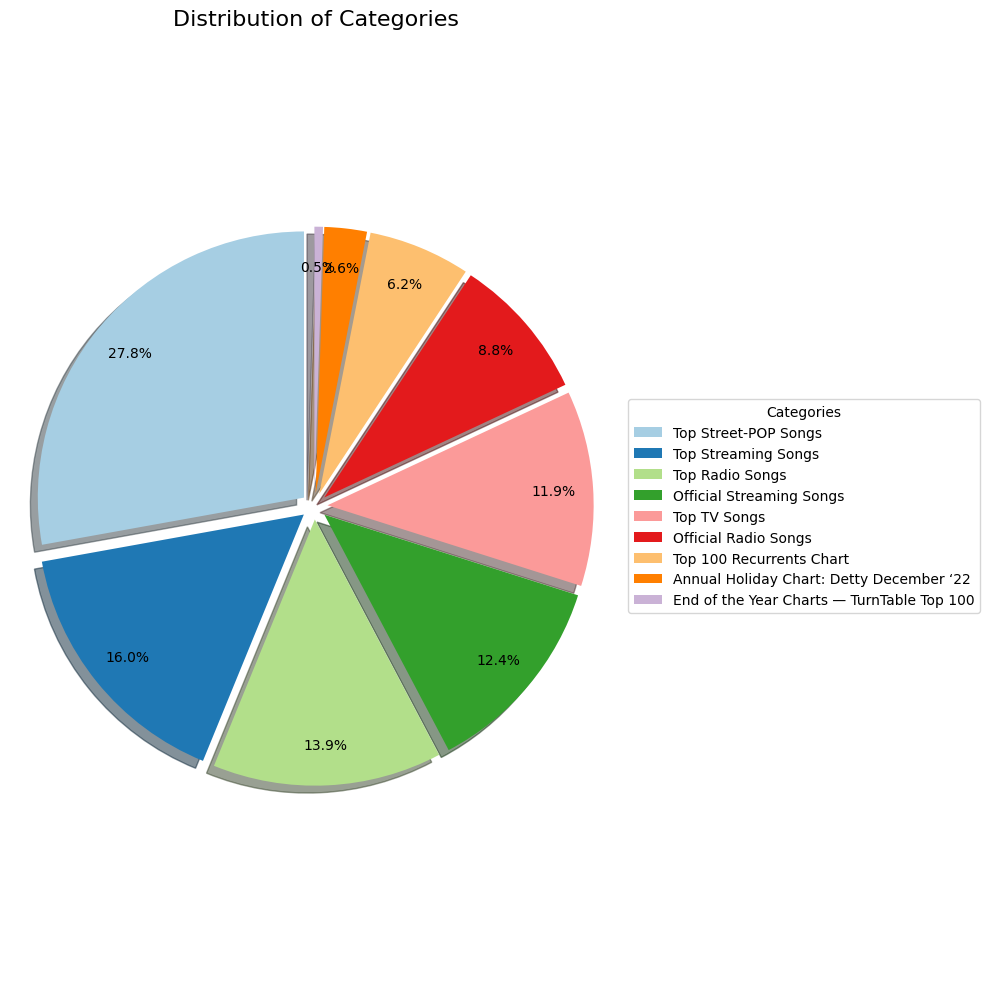

In [ ]:
# Sort category_freq for better visualization in the pie chart
category_freq_sorted = category_freq.sort_values(by='Count', ascending=False)

# Set a custom color palette
colors = sns.color_palette('Paired', len(category_freq_sorted))

# Set the figure size
plt.figure(figsize=(10, 10))

# Plotting the pie chart
wedges, texts, autotexts = plt.pie(
    category_freq_sorted['Count'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85, # Distance of percentage labels from the center
    explode=[0.05] * len(category_freq_sorted), # Slightly explode all slices for better separation
    shadow=True
)

# Make the autopct labels white for better contrast
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(10)

# Remove original text labels, as we will use a legend instead
for text in texts:
    text.set_text('')

# Add a title for clarity
plt.title('Distribution of Categories', fontsize=16)

# Ensure the circle is maintained
plt.axis('equal')

# Add legend with category names
plt.legend(wedges, category_freq_sorted['Category'], title="Categories", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

### Here we have the "Top Street-POP Songs" as the category with most entries which most likely implies a swing in contempory Nigerian music taste. This is a clear indication of the song PBUY been listened too more under the category street pop-songs. For further analysis of this hypothesis, one would consider comparying more songs by the Artist to define the best fit.

# Analysis 3: What is the correlation between rank and days spent on rank across categories?




In [ ]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['Rank'], df['WeeksOnChart'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.5676710136322962
P-value: 6.077011691287099e-18


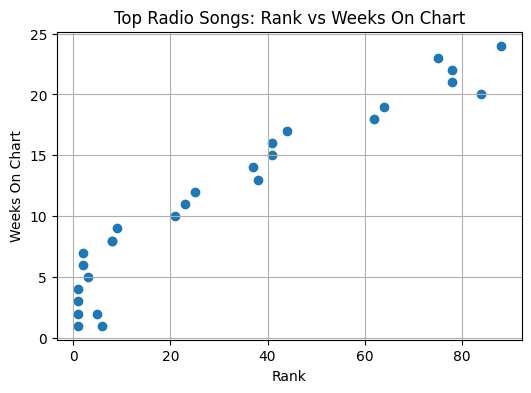

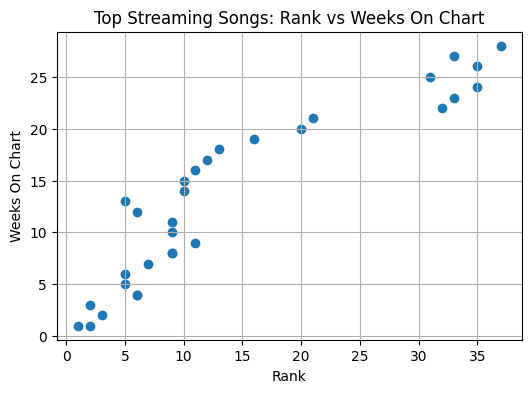

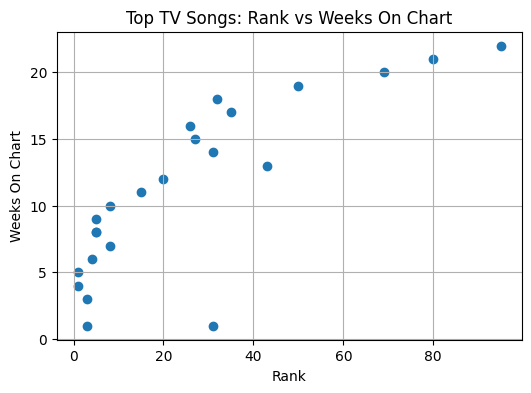

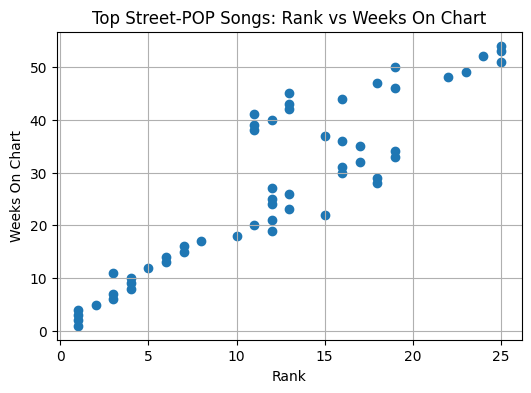

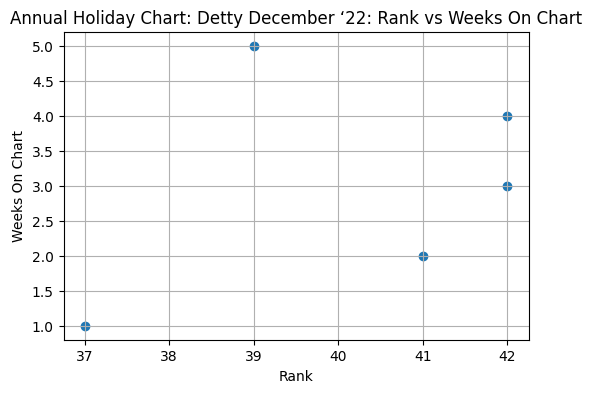

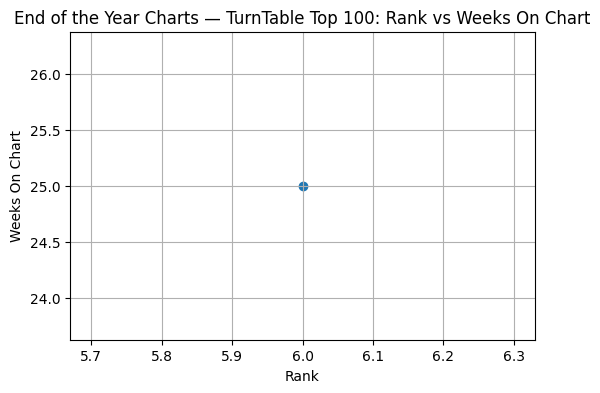

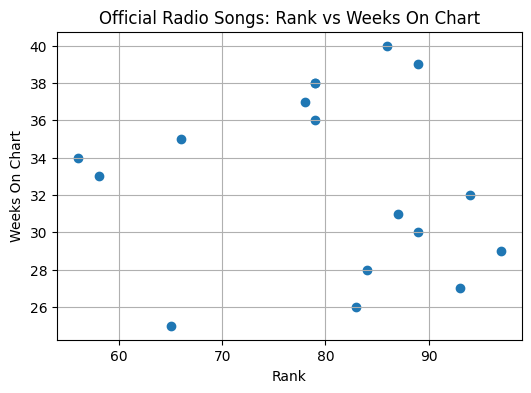

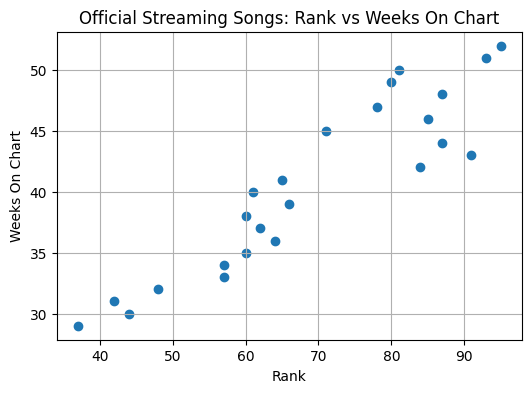

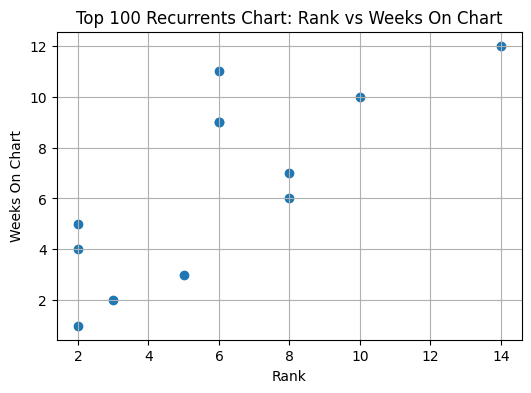

In [ ]:
import matplotlib.pyplot as plt

for category in df['Category'].unique():

    subset = df[df['Category'] == category]

    plt.figure(figsize=(6,4))
    plt.scatter(
        subset['Rank'],
        subset['WeeksOnChart']
    )

    plt.title(f'{category}: Rank vs Weeks On Chart')
    plt.xlabel('Rank')
    plt.ylabel('Weeks On Chart')
    plt.grid(True)

    plt.show()

In [ ]:
for category in df['Category'].unique():

    subset = df[df['Category'] == category]

    corr = subset['Rank'].corr(
        subset['WeeksOnChart']
    )

    print(f'{category}: {corr:.3f}')

Top Radio Songs: 0.958
Top Streaming Songs: 0.919
Top TV Songs: 0.817
Top Street-POP Songs: 0.900
Annual Holiday Chart: Detty December ‘22: 0.365
End of the Year Charts — TurnTable Top 100: nan
Official Radio Songs: -0.105
Official Streaming Songs: 0.922
Top 100 Recurrents Chart: 0.772


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [ ]:
correlations = (
    df.groupby('Category')
      .apply(lambda x: x['Rank'].corr(x['WeeksOnChart']))
      .reset_index(name='Correlation')
)

correlations

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/tmp/ipykernel_5153/730252151.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['Rank'].corr(x['WeeksOnChart']))


,Category,Correlation
0,Annual Holiday Chart: Detty December ‘22,0.364662
1,End of the Year Charts — TurnTable Top 100,NaN
2,Official Radio Songs,-0.104601
3,Official Streaming Songs,0.921774
4,Top 100 Recurrents Chart,0.771554
5,Top Radio Songs,0.957838
6,Top Streaming Songs,0.918645
7,Top Street-POP Songs,0.900020
8,Top TV Songs,0.817122


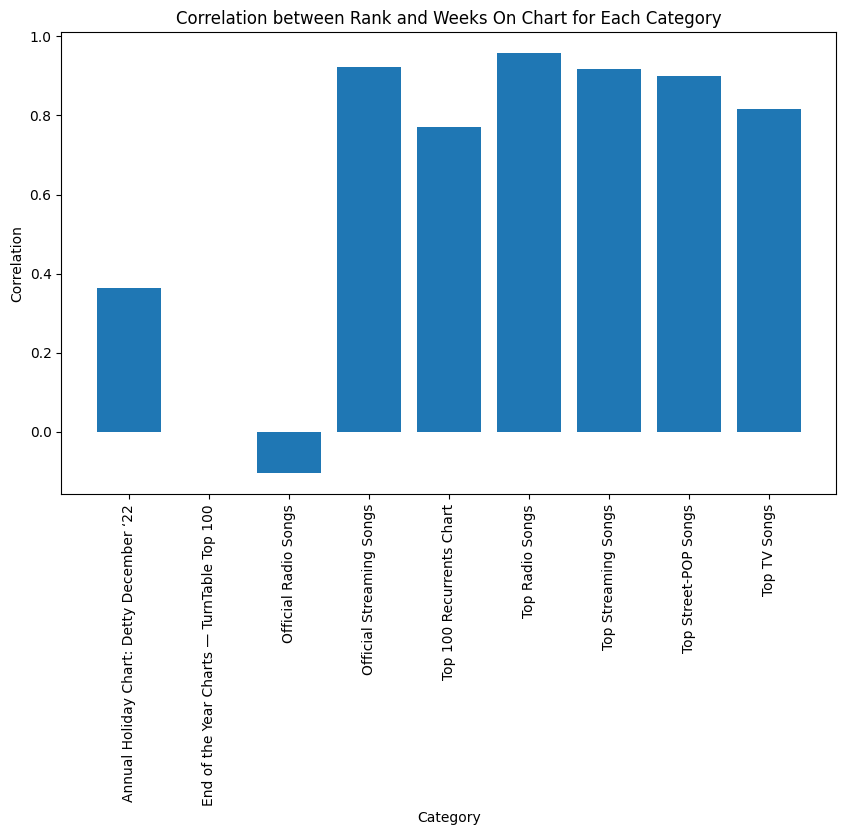

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(correlations['Category'], correlations['Correlation'])
plt.xticks(rotation=90)
plt.xlabel('Category')
plt.ylabel('Correlation')
plt.title('Correlation between Rank and Weeks On Chart for Each Category')
plt.show()

###Conclusion

The analysis reveals strong positive relationships between chart rank and chart longevity across most Nigerian music chart categories. Streaming and digital platforms exhibit the strongest associations, reflecting the ongoing transformation of the Nigerian music industry toward data-driven and audience-driven music consumption patterns.

These findings suggest that sustained audience engagement is a major factor of chart success in contemporary Nigerian music.